In [1]:
# importing packages
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# accessing zipped files
csv_files = glob("zippedData/*.csv")
csv_files

['zippedData/tmdb.movies.csv',
 'zippedData/imdb.title.crew.csv',
 'zippedData/tn.movie_budgets.csv',
 'zippedData/imdb.title.ratings.csv',
 'zippedData/imdb.name.basics.csv',
 'zippedData/imdb.title.principals.csv',
 'zippedData/imdb.title.akas.csv',
 'zippedData/bom.movie_gross.csv',
 'zippedData/imdb.title.basics.csv']

In [3]:
# creating a dictionary for the files
given_files_dict = {}
for given_file in csv_files:
    given_file_cleaned = os.path.basename(given_file).replace(".csv", "").replace(".", "_")
    given_file_df = pd.read_csv(given_file, index_col = 0)
    given_files_dict[given_file_cleaned] = given_file_df

In [4]:
# testing dictionary
given_files_dict.keys()

dict_keys(['tmdb_movies', 'imdb_title_crew', 'tn_movie_budgets', 'imdb_title_ratings', 'imdb_name_basics', 'imdb_title_principals', 'imdb_title_akas', 'bom_movie_gross', 'imdb_title_basics'])

In [5]:
# creating shortcuts for all of the files
tmdb_movies = pd.read_csv('./zippedData/imdb.title.basics.csv')
imdb_title_crew = pd.read_csv('./zippedData/imdb.title.crew.csv')
tn_movie_budgets = pd.read_csv('./zippedData/tn.movie_budgets.csv')
imdb_title_ratings = pd.read_csv('./zippedData/imdb.title.ratings.csv')
imdb_name_basics = pd.read_csv('./zippedData/imdb.name.basics.csv')
imdb_title_principals = pd.read_csv('./zippedData/imdb.title.principals.csv')
imdb_title_akas = pd.read_csv('./zippedData/imdb.title.akas.csv')
bom_movie_gross = pd.read_csv('./zippedData/bom.movie_gross.csv')
imdb_title_basics = pd.read_csv('./zippedData/imdb.title.basics.csv')

# Question 3

# What were the most popular movies online?

In [6]:
# grabbing this data file since I believe it to be the most relivant to the question.
tmdb_movies_df1 = given_files_dict['tmdb_movies']
tmdb_movies_df1

,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...
26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


In [7]:
# dropping dublicates.
tmdb_movies_df1.drop_duplicates(subset='id')

,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...
26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


In [8]:
# dropping more duplictes.
tmdb_movies_df1.drop_duplicates(subset='original_title')

,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...
26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


In [9]:
# dropping columns of irrelivant data.
tmdb_movies_df1.drop(['genre_ids', 'id', 'original_language', 'release_date', 'title'], axis=1, inplace=True)

In [10]:
# dropping columns of irrelivant data.
tmdb_movies_df1.drop(['vote_average', 'vote_count'], axis=1, inplace=True)

In [11]:
# seeing results.
tmdb_movies_df1

,original_title,popularity
0,Harry Potter and the Deathly Hallows: Part 1,33.533
1,How to Train Your Dragon,28.734
2,Iron Man 2,28.515
3,Toy Story,28.005
4,Inception,27.920
...,...,...
26512,Laboratory Conditions,0.600
26513,_EXHIBIT_84xxx_,0.600
26514,The Last One,0.600
26515,Trailer Made,0.600


In [12]:
#  checking my work here.
tmdb_movies_df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26517 entries, 0 to 26516
Data columns (total 2 columns):
original_title    26517 non-null object
popularity        26517 non-null float64
dtypes: float64(1), object(1)
memory usage: 621.5+ KB


In [13]:
# sorting by popularity.
tmdb_movies_df1['popularity']=tmdb_movies_df1['popularity'].astype('int')
tmdb_movies_df1.sort_values(by=('popularity'))

,original_title,popularity
13258,9/11: Simulations,0
13744,The Present,0
13745,Велкам хом,0
13746,Pauly Shore Stands Alone,0
13747,Charles Lloyd - Arrows Into Infinity,0
...,...,...
5179,The Avengers,50
11020,The Hobbit: The Battle of the Five Armies,53
23812,Spider-Man: Into the Spider-Verse,60
11019,John Wick,78


In [14]:
# creating another variable for ease of use.
tmdb_movies_df2 = tmdb_movies_df1.sort_values(by=('popularity'))

In [15]:
# sorting by popularity
tmdb_movies_df3 = tmdb_movies_df2.groupby(['original_title']).max()['popularity'].sort_values( ascending=False)[:10]
tmdb_movies_df3

original_title
Avengers: Infinity War                         80
John Wick                                      78
Spider-Man: Into the Spider-Verse              60
The Hobbit: The Battle of the Five Armies      53
The Avengers                                   50
Guardians of the Galaxy                        49
Ralph Breaks the Internet                      48
Fantastic Beasts: The Crimes of Grindelwald    48
Blade Runner 2049                              48
Spider-Man: Homecoming                         46
Name: popularity, dtype: int64

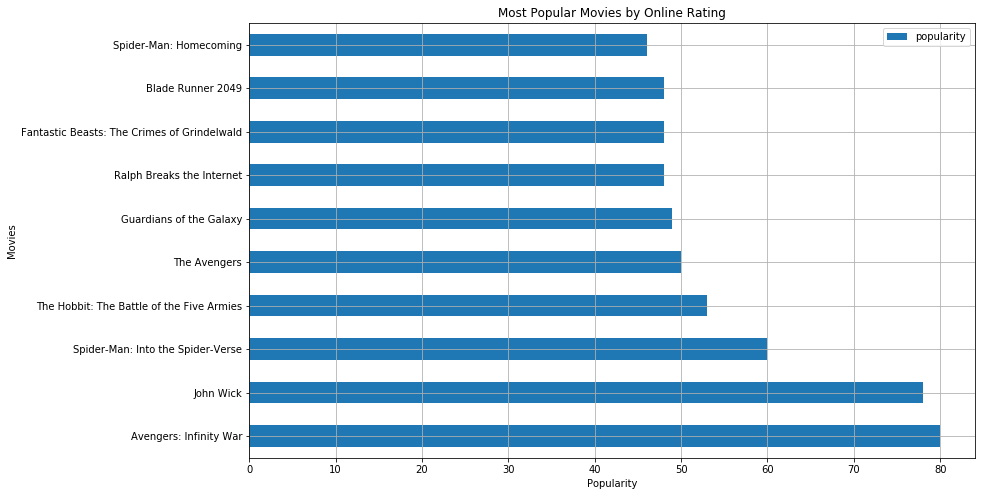

In [16]:
# graphing data
tmdb_movies_df3.plot(kind='barh', figsize=(13,8))
plt.title('Most Popular Movies by Online Rating')
plt.xlabel('Popularity')
plt.ylabel('Movies')
plt.legend()
plt.grid(True)

plt.show()

# Now we're looking for more additional supporting data.

In [17]:
# grabbing the next most relivant data I want to use to answer the "popularity" question.
imdb_title_ratings

,tconst,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [18]:
# creating a database
imdb_title_ratings_df = given_files_dict['imdb_title_ratings']

In [19]:
# checking outcome.
imdb_title_ratings_df

,averagerating,numvotes
tconst,,
tt10356526,8.3,31
tt10384606,8.9,559
tt1042974,6.4,20
tt1043726,4.2,50352
tt1060240,6.5,21
...,...,...
tt9805820,8.1,25
tt9844256,7.5,24
tt9851050,4.7,14


In [20]:
# changing the datatype of numvote to integer.
imdb_title_ratings_df['numvotes']=imdb_title_ratings_df['numvotes'].astype('int')
imdb_title_ratings_df.sort_values(by=('numvotes'))

,averagerating,numvotes
tconst,,
tt1817709,7.2,5
tt5915520,8.2,5
tt7302802,8.8,5
tt7535732,7.2,5
tt7323746,6.4,5
...,...,...
tt0848228,8.1,1183655
tt1853728,8.4,1211405
tt0816692,8.6,1299334


In [21]:
# sorting of the ratings by numvotes 
imdb_title_ratings_df2 =  imdb_title_ratings_df.nlargest(10,['numvotes'])
imdb_title_ratings_df2

,averagerating,numvotes
tconst,,
tt1375666,8.8,1841066
tt1345836,8.4,1387769
tt0816692,8.6,1299334
tt1853728,8.4,1211405
tt0848228,8.1,1183655
tt0993846,8.2,1035358
tt1130884,8.1,1005960
tt2015381,8.1,948394
tt1431045,8.0,820847


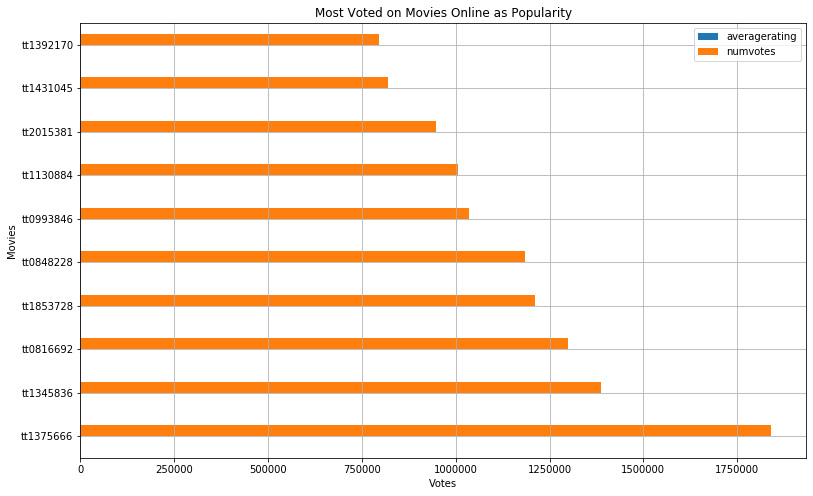

In [23]:
# plotting the data
imdb_title_ratings_df2.plot(kind='barh', figsize=(13,8))
plt.title('Most Voted on Movies Online as Popularity')
plt.xlabel('Votes')
plt.ylabel('Movies')
plt.legend()
plt.grid(True)

plt.show()